In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import sklearn as sk


In [2]:
data = pd.read_csv("hotel_bookings.csv")

print(data.head())
print('--------------------------------------------------------')
print(data.tail())
print('--------------------------------------------------------')


print(data.info())
print('--------------------------------------------------------')
print(data.describe())
print('--------------------------------------------------------')
print(data.shape)
print('--------------------------------------------------------')




          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [3]:
print(data.isna())
print('--------------------------------------------------------')
print(data.isnull()) 
# same as isna
print('--------------------------------------------------------')


        hotel  is_canceled  lead_time  arrival_date_year  arrival_date_month  \
0       False        False      False              False               False   
1       False        False      False              False               False   
2       False        False      False              False               False   
3       False        False      False              False               False   
4       False        False      False              False               False   
...       ...          ...        ...                ...                 ...   
119385  False        False      False              False               False   
119386  False        False      False              False               False   
119387  False        False      False              False               False   
119388  False        False      False              False               False   
119389  False        False      False              False               False   

        arrival_date_week_number  arriv

In [4]:
print(data.isna().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [5]:
data.isna().any() # returns true for col wise if any row in that column has nan value

hotel                             False
is_canceled                       False
lead_time                         False
arrival_date_year                 False
arrival_date_month                False
arrival_date_week_number          False
arrival_date_day_of_month         False
stays_in_weekend_nights           False
stays_in_week_nights              False
adults                            False
children                           True
babies                            False
meal                              False
country                            True
market_segment                    False
distribution_channel              False
is_repeated_guest                 False
previous_cancellations            False
previous_bookings_not_canceled    False
reserved_room_type                False
assigned_room_type                False
booking_changes                   False
deposit_type                      False
agent                              True
company                            True


In [6]:
data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
119385    False
119386    False
119387    False
119388    False
119389    False
Length: 119390, dtype: bool

In [7]:
dd = data.duplicated().sum()
dd
# There are dd rows in your DataFrame that are duplicates of some earlier row.
# These are not necessarily dd unique duplicate values — it’s the total count of duplicate rows.
# The first occurrence of each value is not counted as a duplicate — only the subsequent repeats are counted.

# If a row appears N times, it contributes N-1 to the duplicate count.

np.int64(31994)

In [8]:

data['arrival_date_month'].unique()  # like returns a set per col
data['arrival_date_year'].unique()
 # good for seperatinf categories


array([2015, 2016, 2017])

In [9]:
data.nunique() 
# columnwise all unique values count

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

In [10]:
# axis=0 → move down rows, so you apply the function per column.
# axis=1 → move across columns, so you apply the function per row.

In [11]:
print(data.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')


In [12]:

data.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

<Axes: ylabel='agent'>

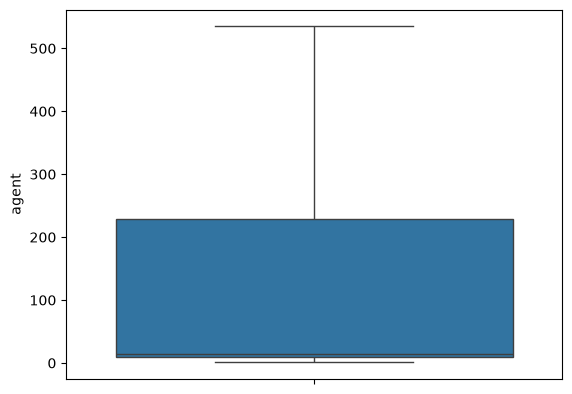

In [13]:
sns.boxplot(data['agent'])
# company agent and country have nulls contry is categorical

<Axes: ylabel='company'>

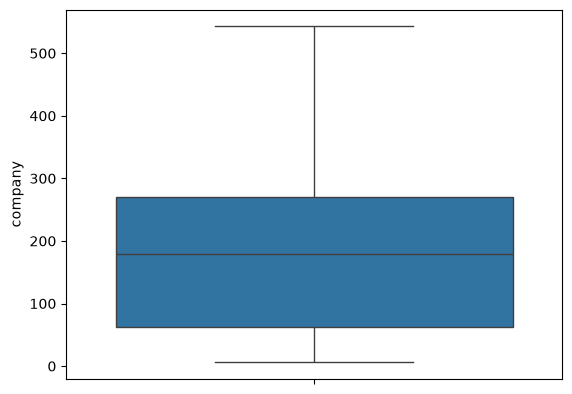

In [14]:
sns.boxplot(data['company'])

In [15]:
# print(data['agent'].mean())

data['company']

data['agent2'] = data['agent'].fillna(data['agent'].mean())
data['company2'] = data['company'].fillna(data['company'].mean())

# print(data['agent'])
print(data['agent2'])

0          86.693382
1          86.693382
2          86.693382
3         304.000000
4         240.000000
             ...    
119385    394.000000
119386      9.000000
119387      9.000000
119388     89.000000
119389      9.000000
Name: agent2, Length: 119390, dtype: float64


In [16]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import sklearn as sk

data = pd.read_csv("hotel_bookings.csv")


LE = LabelEncoder()

data['country1'] = LE.fit_transform(data['country'])

data['country1']

    

0         135
1         135
2          59
3          59
4          59
         ... 
119385     15
119386     56
119387     43
119388     59
119389     43
Name: country1, Length: 119390, dtype: int64

In [17]:
data['hotelcode'] = np.where(data['hotel'].str.contains('City Hotel'),1,0)

data['hotelcode']

0         0
1         0
2         0
3         0
4         0
         ..
119385    1
119386    1
119387    1
119388    1
119389    1
Name: hotelcode, Length: 119390, dtype: int64

In [18]:
# convert to dataframes pd.dataframe
# df = pd.get_dummies(df,columns = ['arrival_date_month'],prefix = 'month')
# from sklearn import 

# feature SCALING 

In [20]:
# scaled using sctarch
X = data['lead_time']

Xmin = X.min()
Xmax = X.max()



data['lead_time_scaled'] = (X - Xmin)/(Xmax - Xmin)
# print(data['lead_time'])
print(data['lead_time_scaled'])



0         342
1         737
2           7
3          13
4          14
         ... 
119385     23
119386    102
119387     34
119388    109
119389    205
Name: lead_time, Length: 119390, dtype: int64
0         0.464043
1         1.000000
2         0.009498
3         0.017639
4         0.018996
            ...   
119385    0.031208
119386    0.138399
119387    0.046133
119388    0.147897
119389    0.278155
Name: lead_time_scaled, Length: 119390, dtype: float64


# STANDARD SCALER MANUALLY AND LIB

In [23]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

data['lead_time_ss'] = ss.fit_transform(data[['lead_time']])

print(data['lead_time_ss'])

0         2.227051
1         5.923385
2        -0.907814
3        -0.851667
4        -0.842309
            ...   
119385   -0.758089
119386   -0.018822
119387   -0.655153
119388    0.046682
119389    0.945032
Name: lead_time_ss, Length: 119390, dtype: float64


In [24]:
x = data['lead_time']

mu = x.mean()

stde = x.std()

data['lead_time_ss_scratch'] = (x-mu)/stde

print(data['lead_time_ss_scratch'])

0         2.227042
1         5.923360
2        -0.907810
3        -0.851664
4        -0.842306
            ...   
119385   -0.758086
119386   -0.018822
119387   -0.655151
119388    0.046682
119389    0.945028
Name: lead_time_ss_scratch, Length: 119390, dtype: float64


In [ ]:
# ROBUST

In [25]:
from sklearn.preprocessing import RobustScaler

rbss = RobustScaler()


data['lead_time_rb'] = rbss.fit_transform(data[['lead_time']])


print(data['lead_time_rb'])

0         1.922535
1         4.704225
2        -0.436620
3        -0.394366
4        -0.387324
            ...   
119385   -0.323944
119386    0.232394
119387   -0.246479
119388    0.281690
119389    0.957746
Name: lead_time_rb, Length: 119390, dtype: float64
